# 2. Pipeline de Dados, Feature Engineering e Modelagem

## Desafio Técnico - Cientista de Dados Pleno

Este notebook implementa:
1. Tratamento de dados ausentes e inconsistentes
2. Criação de tabelas no DuckDB com dados normalizados
3. Consultas SQL para geração de insights e features
4. Treinamento de modelos preditivos (Random Forest e LightGBM)
5. Validação temporal adequada para séries temporais
6. Registro do modelo treinado com MLflow

In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import mlflow
import mlflow.sklearn
import pickle
import os
import json
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 2.1 Ingestão dos Dados

In [2]:
consumo = pd.read_csv('../data/consumo.csv', parse_dates=['date'])
clima = pd.read_csv('../data/clima.csv', parse_dates=['date'])
clientes = pd.read_csv('../data/clientes.csv')

print(f'Consumo:  {consumo.shape}')
print(f'Clima:    {clima.shape}')
print(f'Clientes: {clientes.shape}')

Consumo:  (18000, 3)
Clima:    (900, 4)
Clientes: (100, 2)


## 2.2 Tratamento de Dados Ausentes e Inconsistentes

### 2.2.1 Correção de Regiões Inconsistentes
Clientes com região "Desconhecida" serão atribuídos à região mais frequente dos dados.

In [3]:
# Identificar clientes com região inválida
regioes_validas = sorted(clima.region.unique())
print(f'Regiões válidas: {regioes_validas}')

clientes_invalidos = clientes[clientes.region == 'Desconhecida']
print(f'\nClientes com região inválida: {len(clientes_invalidos)}')
display(clientes_invalidos)

# Estratégia: Atribuir a região com padrão de consumo mais similar
# Para cada cliente com região desconhecida, calcular a média de consumo
# e comparar com a média de cada região
consumo_merge = consumo.merge(clientes, on='client_id')
media_por_regiao = consumo_merge[consumo_merge.region != 'Desconhecida'].groupby('region')['consumption_kwh'].mean()
print('\nMédia de consumo por região válida:')
print(media_por_regiao.round(2))

clientes_corrigido = clientes.copy()
for _, row in clientes_invalidos.iterrows():
    cid = row['client_id']
    media_cliente = consumo[consumo.client_id == cid]['consumption_kwh'].mean()
    # Encontrar a região mais próxima em termos de consumo médio
    regiao_mais_proxima = (media_por_regiao - media_cliente).abs().idxmin()
    clientes_corrigido.loc[clientes_corrigido.client_id == cid, 'region'] = regiao_mais_proxima
    print(f'  {cid}: média={media_cliente:.2f} kWh -> Região atribuída: {regiao_mais_proxima}')

print('\nDistribuição após correção:')
print(clientes_corrigido.region.value_counts())

Regiões válidas: ['Centro', 'Leste', 'Norte', 'Oeste', 'Sul']

Clientes com região inválida: 5


,client_id,region
15,C0015,Desconhecida
50,C0050,Desconhecida
58,C0058,Desconhecida
77,C0077,Desconhecida
92,C0092,Desconhecida



Média de consumo por região válida:
region
Centro    14.95
Leste     14.97
Norte     14.25
Oeste     15.83
Sul       14.69
Name: consumption_kwh, dtype: float64


  C0015: média=17.49 kWh -> Região atribuída: Oeste
  C0050: média=15.16 kWh -> Região atribuída: Leste
  C0058: média=12.19 kWh -> Região atribuída: Norte
  C0077: média=16.41 kWh -> Região atribuída: Oeste
  C0092: média=11.78 kWh -> Região atribuída: Norte

Distribuição após correção:
region
Norte     33
Leste     19
Oeste     17
Centro    16
Sul       15
Name: count, dtype: int64


### 2.2.2 Imputação de Temperaturas Ausentes
Utilizaremos interpolação temporal dentro de cada região.

In [4]:
print(f'Temperaturas ausentes antes: {clima.temperature.isnull().sum()}')

clima_tratado = clima.copy()

# Interpolação linear por região (respeitando a sequência temporal)
for regiao in clima_tratado.region.unique():
    mask = clima_tratado.region == regiao
    clima_tratado.loc[mask, 'temperature'] = (
        clima_tratado.loc[mask, 'temperature']
        .interpolate(method='linear')
    )
    # Forward/backward fill para extremidades
    clima_tratado.loc[mask, 'temperature'] = (
        clima_tratado.loc[mask, 'temperature']
        .fillna(method='ffill').fillna(method='bfill')
    )

print(f'Temperaturas ausentes depois: {clima_tratado.temperature.isnull().sum()}')
print('\nEstatísticas da temperatura tratada:')
display(clima_tratado.groupby('region')['temperature'].describe().round(2))

Temperaturas ausentes antes: 45


Temperaturas ausentes depois: 0

Estatísticas da temperatura tratada:


,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
Centro,180.0,25.25,1.17,22.45,24.47,25.24,26.06,28.64
Leste,180.0,25.03,1.17,21.64,24.21,24.84,25.86,28.49
Norte,180.0,24.99,0.94,22.61,24.44,24.92,25.54,27.97
Oeste,180.0,25.18,1.19,22.08,24.36,25.09,25.88,28.27
Sul,180.0,25.07,1.31,21.31,24.10,25.07,25.98,28.75


## 2.3 DuckDB - Criação de Tabelas Normalizadas

In [5]:
# Criar banco DuckDB
con = duckdb.connect('../data/energy.duckdb')

# Registrar DataFrames como tabelas
con.execute("DROP TABLE IF EXISTS consumo")
con.execute("DROP TABLE IF EXISTS clima")
con.execute("DROP TABLE IF EXISTS clientes")

con.execute("""
    CREATE TABLE clientes AS
    SELECT * FROM clientes_corrigido
""")

con.execute("""
    CREATE TABLE clima AS
    SELECT * FROM clima_tratado
""")

con.execute("""
    CREATE TABLE consumo AS
    SELECT * FROM consumo
""")

# Verificar tabelas
print('Tabelas criadas no DuckDB:')
display(con.execute("SHOW TABLES").fetchdf())

print('\n--- Contagem de registros ---')
for tbl in ['clientes', 'clima', 'consumo']:
    count = con.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    print(f'{tbl}: {count:,} registros')

Tabelas criadas no DuckDB:


,name
0,clientes
1,clima
2,consumo



--- Contagem de registros ---
clientes: 100 registros
clima: 900 registros
consumo: 18,000 registros


## 2.4 Consultas SQL para Insights

In [6]:
# Insight 1: Consumo médio por região e mês
query1 = """
    SELECT 
        cl.region,
        EXTRACT(MONTH FROM co.date) AS mes,
        ROUND(AVG(co.consumption_kwh), 2) AS consumo_medio,
        ROUND(STDDEV(co.consumption_kwh), 2) AS consumo_desvio,
        COUNT(*) AS n_registros
    FROM consumo co
    JOIN clientes cl ON co.client_id = cl.client_id
    GROUP BY cl.region, EXTRACT(MONTH FROM co.date)
    ORDER BY cl.region, mes
"""
print('=== Consumo Médio por Região e Mês ===')
result1 = con.execute(query1).fetchdf()
display(result1)

=== Consumo Médio por Região e Mês ===


,region,mes,consumo_medio,consumo_desvio,n_registros
0,Centro,1,14.90,3.27,496
1,Centro,2,14.86,3.47,448
2,Centro,3,15.00,3.23,496
3,Centro,4,15.07,3.38,480
4,Centro,5,14.84,3.31,496
5,Centro,6,15.02,3.38,464
6,Leste,1,15.03,4.04,589
7,Leste,2,15.03,3.98,532
8,Leste,3,14.95,4.01,589
9,Leste,4,14.88,4.13,570


In [7]:
# Insight 2: Correlação entre temperatura e consumo por região
query2 = """
    SELECT 
        cl.region,
        ROUND(CORR(cli.temperature, co.consumption_kwh), 4) AS corr_temp_consumo,
        ROUND(CORR(cli.humidity, co.consumption_kwh), 4) AS corr_umid_consumo,
        ROUND(AVG(cli.temperature), 2) AS temp_media,
        ROUND(AVG(co.consumption_kwh), 2) AS consumo_medio
    FROM consumo co
    JOIN clientes cl ON co.client_id = cl.client_id
    JOIN clima cli ON cl.region = cli.region AND co.date = cli.date
    GROUP BY cl.region
    ORDER BY corr_temp_consumo DESC
"""
print('=== Correlação Temperatura/Umidade vs Consumo por Região ===')
result2 = con.execute(query2).fetchdf()
display(result2)

=== Correlação Temperatura/Umidade vs Consumo por Região ===


,region,corr_temp_consumo,corr_umid_consumo,temp_media,consumo_medio
0,Norte,-0.0359,0.0067,24.99,14.11
1,Leste,-0.0565,0.0018,25.03,14.98
2,Oeste,-0.0605,-0.0089,25.18,15.96
3,Centro,-0.0606,0.0100,25.25,14.95
4,Sul,-0.0754,-0.0082,25.07,14.69


In [8]:
# Insight 3: Top 10 clientes com maior consumo e sua variabilidade
query3 = """
    SELECT 
        co.client_id,
        cl.region,
        ROUND(AVG(co.consumption_kwh), 2) AS consumo_medio,
        ROUND(STDDEV(co.consumption_kwh), 2) AS desvio_padrao,
        ROUND(MIN(co.consumption_kwh), 2) AS consumo_min,
        ROUND(MAX(co.consumption_kwh), 2) AS consumo_max,
        ROUND(SUM(co.consumption_kwh), 2) AS consumo_total
    FROM consumo co
    JOIN clientes cl ON co.client_id = cl.client_id
    GROUP BY co.client_id, cl.region
    ORDER BY consumo_medio DESC
    LIMIT 10
"""
print('=== Top 10 Maiores Consumidores ===')
display(con.execute(query3).fetchdf())

=== Top 10 Maiores Consumidores ===


,client_id,region,consumo_medio,desvio_padrao,consumo_min,consumo_max,consumo_total
0,C0030,Leste,19.38,2.23,13.43,25.73,3487.80
1,C0028,Leste,19.30,2.16,14.13,27.92,3474.08
2,C0059,Oeste,19.21,2.19,13.52,24.45,3458.67
3,C0096,Leste,19.15,2.30,11.82,24.41,3447.24
4,C0098,Norte,19.06,2.21,12.30,23.55,3431.13
5,C0001,Norte,18.93,2.52,12.61,25.32,3406.71
6,C0017,Norte,18.85,2.32,13.33,24.83,3392.71
7,C0018,Leste,18.77,2.28,11.95,23.71,3378.93
8,C0002,Sul,18.62,2.41,13.36,26.14,3352.43
9,C0038,Sul,18.54,2.16,11.96,23.03,3337.03


In [9]:
# Insight 4: Padrão de consumo por dia da semana
query4 = """
    SELECT 
        DAYOFWEEK(co.date) AS dia_semana,
        CASE DAYOFWEEK(co.date)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda'
            WHEN 2 THEN 'Terça'
            WHEN 3 THEN 'Quarta'
            WHEN 4 THEN 'Quinta'
            WHEN 5 THEN 'Sexta'
            WHEN 6 THEN 'Sábado'
        END AS nome_dia,
        ROUND(AVG(co.consumption_kwh), 2) AS consumo_medio,
        ROUND(STDDEV(co.consumption_kwh), 2) AS desvio_padrao
    FROM consumo co
    GROUP BY DAYOFWEEK(co.date)
    ORDER BY dia_semana
"""
print('=== Consumo Médio por Dia da Semana ===')
display(con.execute(query4).fetchdf())

=== Consumo Médio por Dia da Semana ===


,dia_semana,nome_dia,consumo_medio,desvio_padrao
0,0,Domingo,14.78,3.82
1,1,Segunda,14.79,3.68
2,2,Terça,14.86,3.69
3,3,Quarta,14.77,3.77
4,4,Quinta,14.84,3.68
5,5,Sexta,14.84,3.73
6,6,Sábado,14.81,3.74


## 2.5 Feature Engineering via SQL

In [10]:
# Criar tabela de features usando SQL no DuckDB
query_features = """
    WITH consumo_com_regiao AS (
        SELECT 
            co.client_id,
            co.date,
            co.consumption_kwh,
            cl.region
        FROM consumo co
        JOIN clientes cl ON co.client_id = cl.client_id
    ),
    consumo_com_clima AS (
        SELECT
            ccr.*,
            cli.temperature,
            cli.humidity
        FROM consumo_com_regiao ccr
        LEFT JOIN clima cli ON ccr.region = cli.region AND ccr.date = cli.date
    ),
    features_lag AS (
        SELECT
            *,
            -- Features temporais
            EXTRACT(MONTH FROM date) AS month,
            EXTRACT(DOW FROM date) AS day_of_week,
            EXTRACT(DAY FROM date) AS day_of_month,
            EXTRACT(WEEK FROM date) AS week_of_year,
            CASE WHEN EXTRACT(DOW FROM date) IN (0, 6) THEN 1 ELSE 0 END AS is_weekend,
            
            -- Lag features (consumo dos dias anteriores)
            LAG(consumption_kwh, 1) OVER (PARTITION BY client_id ORDER BY date) AS consumption_lag1,
            LAG(consumption_kwh, 2) OVER (PARTITION BY client_id ORDER BY date) AS consumption_lag2,
            LAG(consumption_kwh, 3) OVER (PARTITION BY client_id ORDER BY date) AS consumption_lag3,
            LAG(consumption_kwh, 7) OVER (PARTITION BY client_id ORDER BY date) AS consumption_lag7,
            
            -- Médias móveis
            AVG(consumption_kwh) OVER (
                PARTITION BY client_id ORDER BY date
                ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
            ) AS consumption_ma7,
            AVG(consumption_kwh) OVER (
                PARTITION BY client_id ORDER BY date
                ROWS BETWEEN 14 PRECEDING AND 1 PRECEDING
            ) AS consumption_ma14,
            AVG(consumption_kwh) OVER (
                PARTITION BY client_id ORDER BY date
                ROWS BETWEEN 30 PRECEDING AND 1 PRECEDING
            ) AS consumption_ma30,
            
            -- Desvio padrão móvel
            STDDEV(consumption_kwh) OVER (
                PARTITION BY client_id ORDER BY date
                ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
            ) AS consumption_std7,
            
            -- Min/Max móvel
            MIN(consumption_kwh) OVER (
                PARTITION BY client_id ORDER BY date
                ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
            ) AS consumption_min7,
            MAX(consumption_kwh) OVER (
                PARTITION BY client_id ORDER BY date
                ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
            ) AS consumption_max7,
            
            -- Lag de temperatura
            LAG(temperature, 1) OVER (PARTITION BY client_id ORDER BY date) AS temp_lag1
            
        FROM consumo_com_clima
    )
    SELECT * FROM features_lag
    WHERE consumption_lag7 IS NOT NULL  -- Remover primeiros 7 dias sem lags
    ORDER BY client_id, date
"""

df_features = con.execute(query_features).fetchdf()
print(f'Dataset com features: {df_features.shape}')
print(f'\nColunas: {list(df_features.columns)}')
display(df_features.head())

Dataset com features: (17300, 22)

Colunas: ['client_id', 'date', 'consumption_kwh', 'region', 'temperature', 'humidity', 'month', 'day_of_week', 'day_of_month', 'week_of_year', 'is_weekend', 'consumption_lag1', 'consumption_lag2', 'consumption_lag3', 'consumption_lag7', 'consumption_ma7', 'consumption_ma14', 'consumption_ma30', 'consumption_std7', 'consumption_min7', 'consumption_max7', 'temp_lag1']


,client_id,date,consumption_kwh,region,temperature,humidity,month,day_of_week,day_of_month,week_of_year,...,consumption_lag2,consumption_lag3,consumption_lag7,consumption_ma7,consumption_ma14,consumption_ma30,consumption_std7,consumption_min7,consumption_max7,temp_lag1
0,C0000,2023-01-08,19.35,Norte,24.739062,60.884375,1,0,8,1,...,15.87,19.81,18.64,18.230000,18.230000,18.230000,1.586075,15.87,20.3,22.606250
1,C0000,2023-01-09,18.30,Norte,26.871875,61.200000,1,1,9,2,...,20.30,15.87,16.63,18.331429,18.370000,18.370000,1.638500,15.87,20.3,24.739062
2,C0000,2023-01-10,13.34,Norte,24.846875,61.028125,1,2,10,2,...,19.35,20.30,18.11,18.570000,18.362222,18.362222,1.461495,15.87,20.3,26.871875
3,C0000,2023-01-11,15.67,Norte,25.696875,60.621875,1,3,11,2,...,18.30,19.35,18.25,17.888571,17.860000,17.860000,2.473415,13.34,20.3,24.846875
4,C0000,2023-01-12,19.08,Norte,24.981250,62.293750,1,4,12,2,...,13.34,18.30,19.81,17.520000,17.660909,17.660909,2.599590,13.34,20.3,25.696875


In [11]:
# Verificar e tratar nulos remanescentes
print('Valores nulos por coluna:')
null_counts = df_features.isnull().sum()
print(null_counts[null_counts > 0])

# Dropar linhas com nulos residuais (poucos)
df_features = df_features.dropna()
print(f'\nDataset final: {df_features.shape}')

Valores nulos por coluna:
Series([], dtype: int64)

Dataset final: (17300, 22)


## 2.6 Validação Temporal - Split Treino/Teste

Para séries temporais, utilizamos split temporal: treino nos primeiros meses e teste no último mês.
Isso evita data leakage e simula o cenário real de previsão futura.

In [12]:
# Split temporal: treino até 31/maio, teste em junho
cutoff_date = pd.Timestamp('2023-06-01')

train_mask = df_features['date'] < cutoff_date
test_mask = df_features['date'] >= cutoff_date

# Features para o modelo
feature_cols = [
    'temperature', 'humidity', 'month', 'day_of_week', 'day_of_month',
    'week_of_year', 'is_weekend',
    'consumption_lag1', 'consumption_lag2', 'consumption_lag3', 'consumption_lag7',
    'consumption_ma7', 'consumption_ma14', 'consumption_ma30',
    'consumption_std7', 'consumption_min7', 'consumption_max7',
    'temp_lag1'
]

target = 'consumption_kwh'

# Encode região
le = LabelEncoder()
df_features['region_encoded'] = le.fit_transform(df_features['region'])
feature_cols.append('region_encoded')

X_train = df_features.loc[train_mask, feature_cols]
y_train = df_features.loc[train_mask, target]
X_test = df_features.loc[test_mask, feature_cols]
y_test = df_features.loc[test_mask, target]

print(f'Treino: {X_train.shape[0]:,} amostras ({df_features.loc[train_mask, "date"].min().date()} a {df_features.loc[train_mask, "date"].max().date()})')
print(f'Teste:  {X_test.shape[0]:,} amostras ({df_features.loc[test_mask, "date"].min().date()} a {df_features.loc[test_mask, "date"].max().date()})')
print(f'Features: {len(feature_cols)}')

Treino: 14,400 amostras (2023-01-08 a 2023-05-31)
Teste:  2,900 amostras (2023-06-01 a 2023-06-29)
Features: 19


## 2.7 Treinamento dos Modelos

### Modelo 1: Random Forest Regressor

In [13]:
# Configurar MLflow
mlflow.set_tracking_uri('file:///' + os.path.abspath('../models/mlruns').replace('\\', '/'))
mlflow.set_experiment('energy_consumption_prediction')

def evaluate_model(y_true, y_pred, model_name):
    """Calcula e retorna métricas de avaliação."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f'\n=== {model_name} ===')
    print(f'MAE:  {mae:.4f} kWh')
    print(f'RMSE: {rmse:.4f} kWh')
    print(f'R²:   {r2:.4f}')
    print(f'MAPE: {mape:.2f}%')
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape}

print('Funções auxiliares definidas.')

Funções auxiliares definidas.

In [14]:
# Modelo 1: Random Forest
with mlflow.start_run(run_name='random_forest') as run:
    rf_params = {
        'n_estimators': 200,
        'max_depth': 15,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'random_state': 42,
        'n_jobs': -1
    }
    
    rf_model = RandomForestRegressor(**rf_params)
    rf_model.fit(X_train, y_train)
    
    # Predições
    rf_pred_train = rf_model.predict(X_train)
    rf_pred_test = rf_model.predict(X_test)
    
    # Métricas
    rf_metrics_train = evaluate_model(y_train, rf_pred_train, 'Random Forest (Treino)')
    rf_metrics_test = evaluate_model(y_test, rf_pred_test, 'Random Forest (Teste)')
    
    # Log no MLflow
    mlflow.log_params(rf_params)
    mlflow.log_metrics({f'test_{k}': v for k, v in rf_metrics_test.items()})
    mlflow.log_metrics({f'train_{k}': v for k, v in rf_metrics_train.items()})
    mlflow.sklearn.log_model(rf_model, 'random_forest_model')
    
    rf_run_id = run.info.run_id
    print(f'\nMLflow Run ID: {rf_run_id}')


=== Random Forest (Treino) ===
MAE:  1.0957 kWh
RMSE: 1.3784 kWh
R²:   0.8632
MAPE: 8.28%

=== Random Forest (Teste) ===
MAE:  1.8620 kWh
RMSE: 2.3308 kWh
R²:   0.6117
MAPE: 13.91%


2026/02/10 11:24:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/02/10 11:25:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



MLflow Run ID: 1986c610fa904e09a72e45f9ffacad52


### Modelo 2: LightGBM Regressor

In [15]:
# Modelo 2: LightGBM
with mlflow.start_run(run_name='lightgbm') as run:
    lgb_params = {
        'n_estimators': 300,
        'max_depth': 10,
        'learning_rate': 0.05,
        'num_leaves': 31,
        'min_child_samples': 10,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'verbose': -1
    }
    
    lgb_model = lgb.LGBMRegressor(**lgb_params)
    lgb_model.fit(X_train, y_train)
    
    # Predições
    lgb_pred_train = lgb_model.predict(X_train)
    lgb_pred_test = lgb_model.predict(X_test)
    
    # Métricas
    lgb_metrics_train = evaluate_model(y_train, lgb_pred_train, 'LightGBM (Treino)')
    lgb_metrics_test = evaluate_model(y_test, lgb_pred_test, 'LightGBM (Teste)')
    
    # Log no MLflow
    mlflow.log_params(lgb_params)
    mlflow.log_metrics({f'test_{k}': v for k, v in lgb_metrics_test.items()})
    mlflow.log_metrics({f'train_{k}': v for k, v in lgb_metrics_train.items()})
    mlflow.sklearn.log_model(lgb_model, 'lightgbm_model')
    
    lgb_run_id = run.info.run_id
    print(f'\nMLflow Run ID: {lgb_run_id}')


=== LightGBM (Treino) ===
MAE:  1.5254 kWh
RMSE: 1.9209 kWh
R²:   0.7344
MAPE: 11.57%

=== LightGBM (Teste) ===
MAE:  1.8607 kWh
RMSE: 2.3257 kWh
R²:   0.6134
MAPE: 13.81%


2026/02/10 11:25:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/02/10 11:25:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



MLflow Run ID: ad4960b5cc674350ba9f0e75028c8308


## 2.8 Comparação dos Modelos

In [16]:
# Comparação lado a lado
comparison = pd.DataFrame({
    'Métrica': ['MAE (kWh)', 'RMSE (kWh)', 'R²', 'MAPE (%)'],
    'Random Forest': [rf_metrics_test['mae'], rf_metrics_test['rmse'], rf_metrics_test['r2'], rf_metrics_test['mape']],
    'LightGBM': [lgb_metrics_test['mae'], lgb_metrics_test['rmse'], lgb_metrics_test['r2'], lgb_metrics_test['mape']]
}).set_index('Métrica')

print('=== Comparação dos Modelos (Teste) ===')
display(comparison.round(4))

# Determinar melhor modelo
best_model_name = 'LightGBM' if lgb_metrics_test['rmse'] < rf_metrics_test['rmse'] else 'Random Forest'
best_model = lgb_model if best_model_name == 'LightGBM' else rf_model
best_pred = lgb_pred_test if best_model_name == 'LightGBM' else rf_pred_test
print(f'\nMelhor modelo: {best_model_name}')

=== Comparação dos Modelos (Teste) ===


,Random Forest,LightGBM
Métrica,,
MAE (kWh),1.8620,1.8607
RMSE (kWh),2.3308,2.3257
R²,0.6117,0.6134
MAPE (%),13.9108,13.8129



Melhor modelo: LightGBM


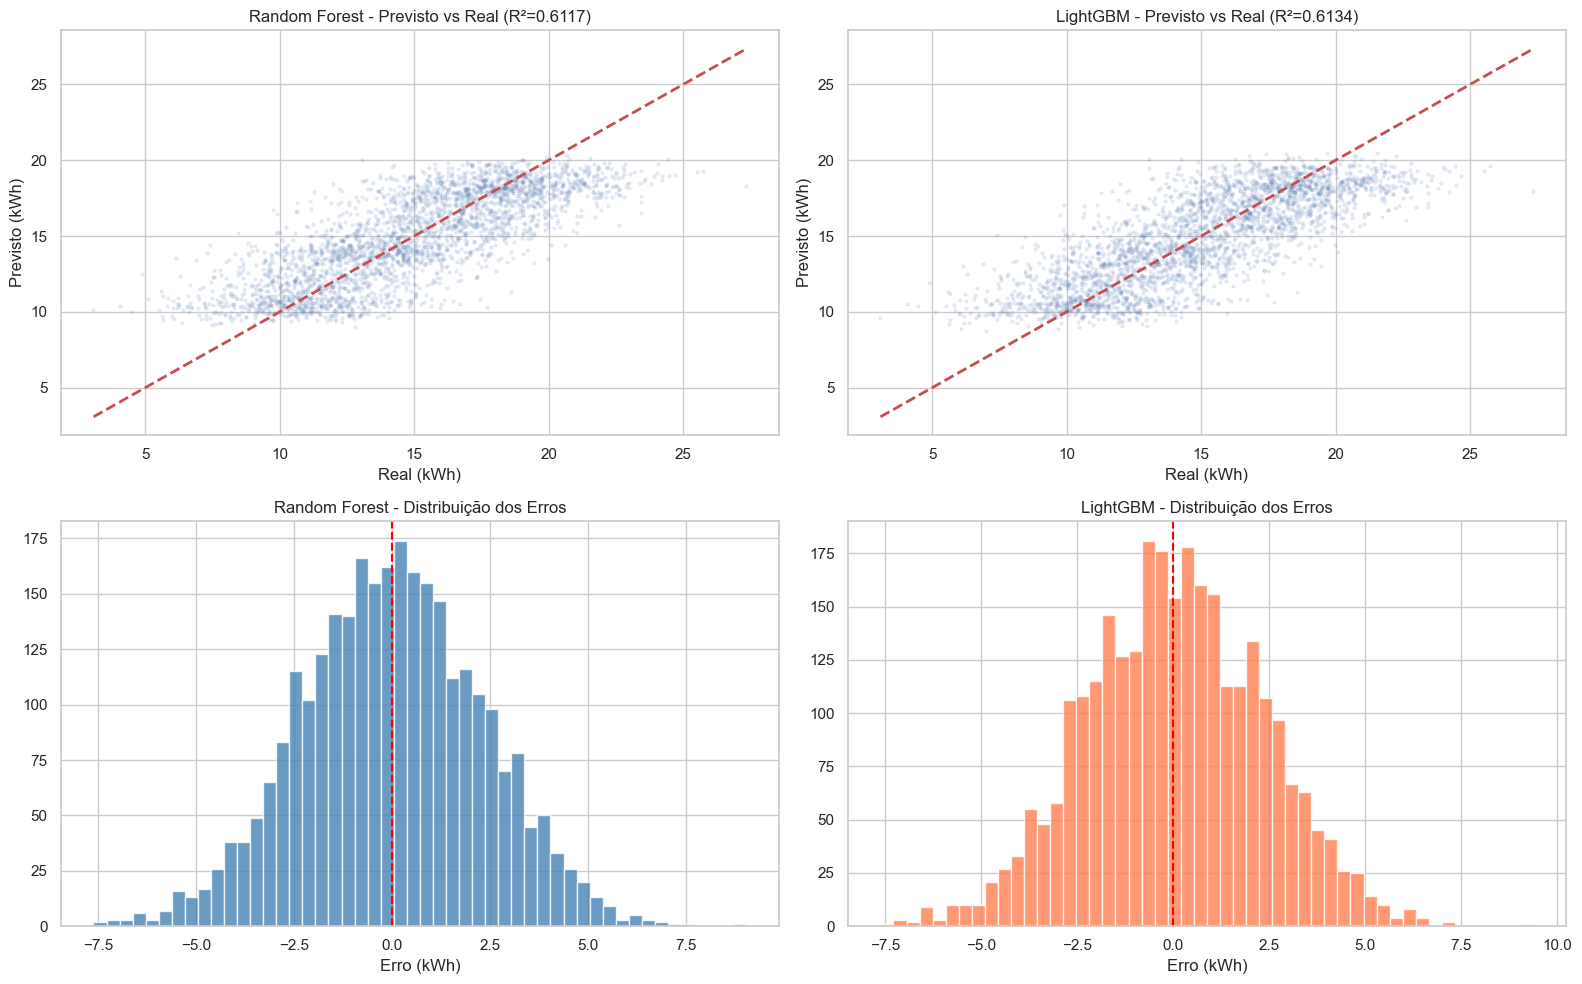

In [17]:
# Visualização das previsões vs real
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Random Forest: Previsto vs Real
axes[0, 0].scatter(y_test, rf_pred_test, alpha=0.1, s=5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0, 0].set_xlabel('Real (kWh)')
axes[0, 0].set_ylabel('Previsto (kWh)')
axes[0, 0].set_title(f'Random Forest - Previsto vs Real (R²={rf_metrics_test["r2"]:.4f})')

# LightGBM: Previsto vs Real
axes[0, 1].scatter(y_test, lgb_pred_test, alpha=0.1, s=5)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0, 1].set_xlabel('Real (kWh)')
axes[0, 1].set_ylabel('Previsto (kWh)')
axes[0, 1].set_title(f'LightGBM - Previsto vs Real (R²={lgb_metrics_test["r2"]:.4f})')

# Random Forest: Distribuição dos erros
rf_errors = y_test.values - rf_pred_test
axes[1, 0].hist(rf_errors, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1, 0].axvline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Erro (kWh)')
axes[1, 0].set_title('Random Forest - Distribuição dos Erros')

# LightGBM: Distribuição dos erros
lgb_errors = y_test.values - lgb_pred_test
axes[1, 1].hist(lgb_errors, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1, 1].axvline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Erro (kWh)')
axes[1, 1].set_title('LightGBM - Distribuição dos Erros')

plt.tight_layout()
plt.savefig('../notebooks/fig_modelos_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

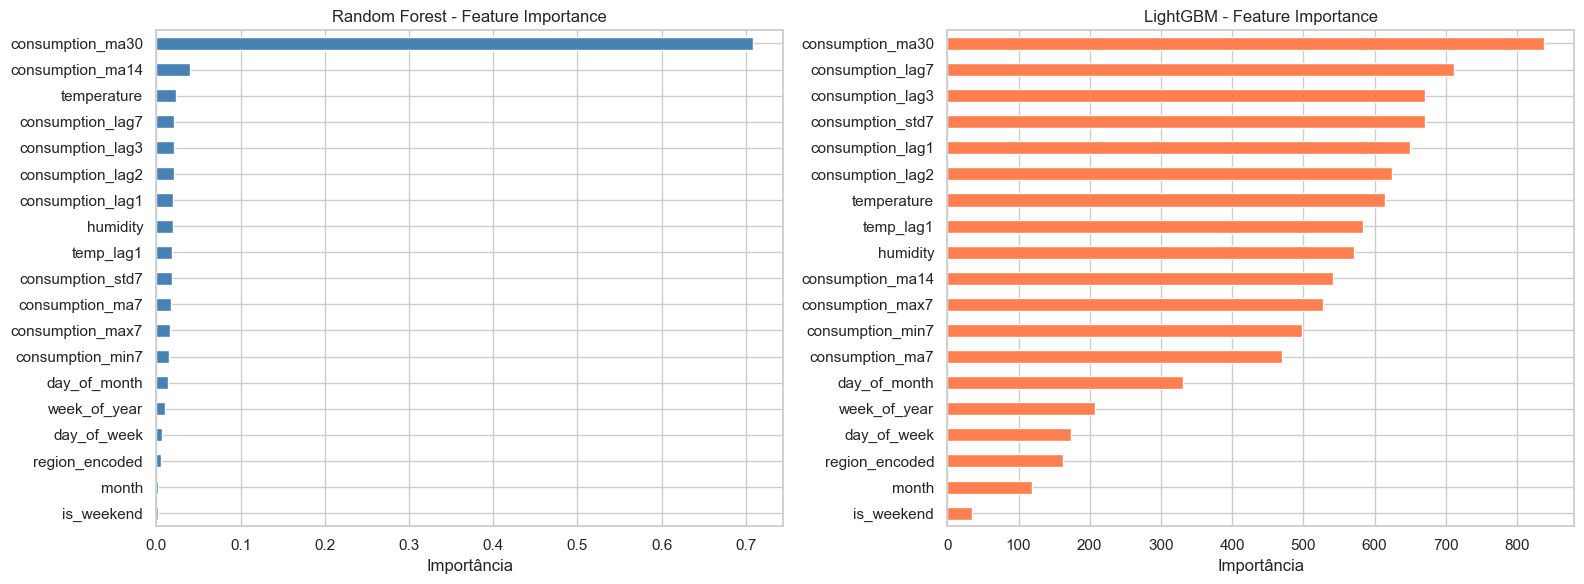

In [18]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
rf_importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest - Feature Importance')
axes[0].set_xlabel('Importância')

# LightGBM
lgb_importance = pd.Series(lgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
lgb_importance.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('LightGBM - Feature Importance')
axes[1].set_xlabel('Importância')

plt.tight_layout()
plt.savefig('../notebooks/fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.9 Validação Temporal com Expanding Window

In [19]:
# Expanding window cross-validation
# Treinar com janela crescente e testar mês a mês
months = sorted(df_features['date'].dt.to_period('M').unique())
print(f'Meses disponíveis: {[str(m) for m in months]}')

cv_results = []

# Usar os meses 3 a 6 como teste (março a junho), sempre treinando com todos os meses anteriores
for i in range(2, len(months)):
    test_month = months[i]
    train_end = test_month.start_time
    test_end = (test_month + 1).start_time
    
    cv_train = df_features[df_features['date'] < train_end]
    cv_test = df_features[(df_features['date'] >= train_end) & (df_features['date'] < test_end)]
    
    if len(cv_train) == 0 or len(cv_test) == 0:
        continue
    
    # Treinar LightGBM
    cv_model = lgb.LGBMRegressor(**lgb_params)
    cv_model.fit(cv_train[feature_cols], cv_train[target])
    cv_pred = cv_model.predict(cv_test[feature_cols])
    
    mae = mean_absolute_error(cv_test[target], cv_pred)
    rmse = np.sqrt(mean_squared_error(cv_test[target], cv_pred))
    r2 = r2_score(cv_test[target], cv_pred)
    
    cv_results.append({
        'test_month': str(test_month),
        'train_size': len(cv_train),
        'test_size': len(cv_test),
        'mae': mae,
        'rmse': rmse,
        'r2': r2
    })
    print(f'  Mês {test_month}: treino={len(cv_train):,} | teste={len(cv_test):,} | MAE={mae:.4f} | R²={r2:.4f}')

cv_df = pd.DataFrame(cv_results)
print(f'\n=== Média da Validação Temporal ===')
print(f'MAE médio:  {cv_df.mae.mean():.4f} ± {cv_df.mae.std():.4f}')
print(f'RMSE médio: {cv_df.rmse.mean():.4f} ± {cv_df.rmse.std():.4f}')
print(f'R² médio:   {cv_df.r2.mean():.4f} ± {cv_df.r2.std():.4f}')

Meses disponíveis: ['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06']


  Mês 2023-03: treino=5,200 | teste=3,100 | MAE=1.8540 | R²=0.6025


  Mês 2023-04: treino=8,300 | teste=3,000 | MAE=1.8528 | R²=0.6077


  Mês 2023-05: treino=11,300 | teste=3,100 | MAE=1.8664 | R²=0.6191


  Mês 2023-06: treino=14,400 | teste=2,900 | MAE=1.8607 | R²=0.6134

=== Média da Validação Temporal ===
MAE médio:  1.8585 ± 0.0063
RMSE médio: 2.3278 ± 0.0054
R² médio:   0.6107 ± 0.0072


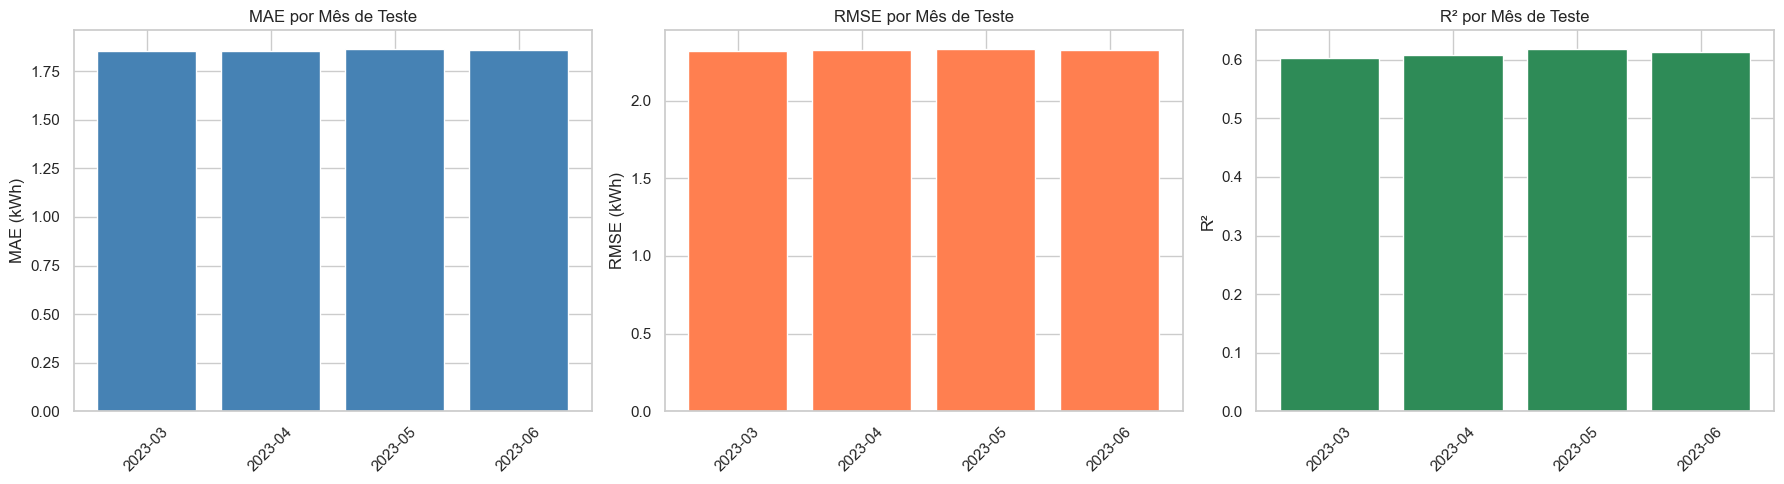

In [20]:
# Visualizar resultados da validação temporal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(cv_df.test_month, cv_df.mae, color='steelblue', edgecolor='white')
axes[0].set_title('MAE por Mês de Teste')
axes[0].set_ylabel('MAE (kWh)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(cv_df.test_month, cv_df.rmse, color='coral', edgecolor='white')
axes[1].set_title('RMSE por Mês de Teste')
axes[1].set_ylabel('RMSE (kWh)')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(cv_df.test_month, cv_df.r2, color='seagreen', edgecolor='white')
axes[2].set_title('R² por Mês de Teste')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../notebooks/fig_validacao_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.10 Salvamento do Modelo e Artefatos

In [21]:
# Salvar modelos com pickle versionado
os.makedirs('../models', exist_ok=True)

version = datetime.now().strftime('%Y%m%d_%H%M%S')

# Salvar Random Forest
rf_path = f'../models/random_forest_v{version}.pkl'
with open(rf_path, 'wb') as f:
    pickle.dump(rf_model, f)
print(f'Random Forest salvo: {rf_path}')

# Salvar LightGBM
lgb_path = f'../models/lightgbm_v{version}.pkl'
with open(lgb_path, 'wb') as f:
    pickle.dump(lgb_model, f)
print(f'LightGBM salvo: {lgb_path}')

# Salvar Label Encoder
le_path = f'../models/label_encoder_v{version}.pkl'
with open(le_path, 'wb') as f:
    pickle.dump(le, f)
print(f'LabelEncoder salvo: {le_path}')

# Salvar metadados do modelo
metadata = {
    'version': version,
    'best_model': best_model_name,
    'feature_cols': feature_cols,
    'target': target,
    'train_period': f'{df_features.loc[train_mask, "date"].min().date()} a {df_features.loc[train_mask, "date"].max().date()}',
    'test_period': f'{df_features.loc[test_mask, "date"].min().date()} a {df_features.loc[test_mask, "date"].max().date()}',
    'metrics': {
        'random_forest': rf_metrics_test,
        'lightgbm': lgb_metrics_test
    },
    'cv_results': cv_results
}

meta_path = f'../models/metadata_v{version}.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print(f'Metadados salvos: {meta_path}')

# Salvar features processadas para o dashboard
df_features.to_parquet('../data/features_processed.parquet', index=False)

# Salvar previsões para o dashboard
predictions = df_features.loc[test_mask].copy()
predictions['rf_prediction'] = rf_pred_test
predictions['lgb_prediction'] = lgb_pred_test
predictions.to_parquet('../data/predictions.parquet', index=False)
print('Features e previsões salvas em Parquet.')

Random Forest salvo: ../models/random_forest_v20260210_112547.pkl
LightGBM salvo: ../models/lightgbm_v20260210_112547.pkl
LabelEncoder salvo: ../models/label_encoder_v20260210_112547.pkl
Metadados salvos: ../models/metadata_v20260210_112547.json


Features e previsões salvas em Parquet.


In [22]:
# Fechar conexão DuckDB
con.close()
print('Conexão DuckDB fechada.')
print('\n=== Pipeline completo! ===')

Conexão DuckDB fechada.

=== Pipeline completo! ===
